# Parkinson's Disease — Data Cleaning & Feature Engineering

Pipeline:
1. Drop the recording-name column
2. Engineer `frequency_range`, `jitter_avg`, `shimmer_avg`, `voice_to_noise`
3. Save cleaned dataset to `data/parkinsons_cleaned.csv`

There are no missing values — UCI Parkinson's is already clean.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, drop_id, create_features, preprocess_data)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/parkinsons.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (195, 24)


,name,Fo_Hz,Fhi_Hz,Flo_Hz,Jitter_pct,Jitter_Abs,RAP,PPQ,Jitter_DDP,Shimmer,...,Shimmer_DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 2. Missing / Invalid Values

In [3]:
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")

Total missing values: 0
Duplicate rows      : 0


## 3. Drop ID Column

In [4]:
df_no_id = drop_id(df)
print(f"After dropping name: {df_no_id.shape}")
df_no_id.head()

After dropping name: (195, 23)


,Fo_Hz,Fhi_Hz,Flo_Hz,Jitter_pct,Jitter_Abs,RAP,PPQ,Jitter_DDP,Shimmer,Shimmer_dB,...,Shimmer_DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 4. Distribution Check Before Feature Engineering

In [5]:
features = [c for c in df_no_id.columns if c != "status"]
print(f"# of original features: {len(features)}")
df_no_id[features].describe().round(3).T.head(10)

# of original features: 22


,count,mean,std,min,25%,50%,75%,max
Fo_Hz,195.0,154.229,41.390,88.333,117.572,148.790,182.769,260.105
Fhi_Hz,195.0,197.105,91.492,102.145,134.862,175.829,224.206,592.030
Flo_Hz,195.0,116.325,43.521,65.476,84.291,104.315,140.019,239.170
Jitter_pct,195.0,0.006,0.005,0.002,0.003,0.005,0.007,0.033
Jitter_Abs,195.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
RAP,195.0,0.003,0.003,0.001,0.002,0.002,0.004,0.021
PPQ,195.0,0.003,0.003,0.001,0.002,0.003,0.004,0.020
Jitter_DDP,195.0,0.010,0.009,0.002,0.005,0.007,0.012,0.064
Shimmer,195.0,0.030,0.019,0.010,0.017,0.023,0.038,0.119
Shimmer_dB,195.0,0.282,0.195,0.085,0.148,0.221,0.350,1.302


## 5. Feature Engineering

We add 4 summary features:
- `frequency_range` (Fhi − Flo) — vocal range
- `jitter_avg` — average over all jitter measurements
- `shimmer_avg` — average over all shimmer measurements
- `voice_to_noise` — HNR / NHR ratio

In [6]:
df_feat = create_features(df_no_id)
new_cols = [c for c in df_feat.columns if c not in df_no_id.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["status"]].head()

New features: ['frequency_range', 'jitter_avg', 'shimmer_avg', 'voice_to_noise']


,frequency_range,jitter_avg,shimmer_avg,voice_to_noise,status
0,82.305,0.005648,0.117662,951.288966,1
1,34.831,0.007062,0.171578,989.372681,1
2,19.556,0.008034,0.136636,1577.616381,1
3,26.505,0.007422,0.145784,1525.794418,1
4,31.126,0.009648,0.167220,1111.997673,1


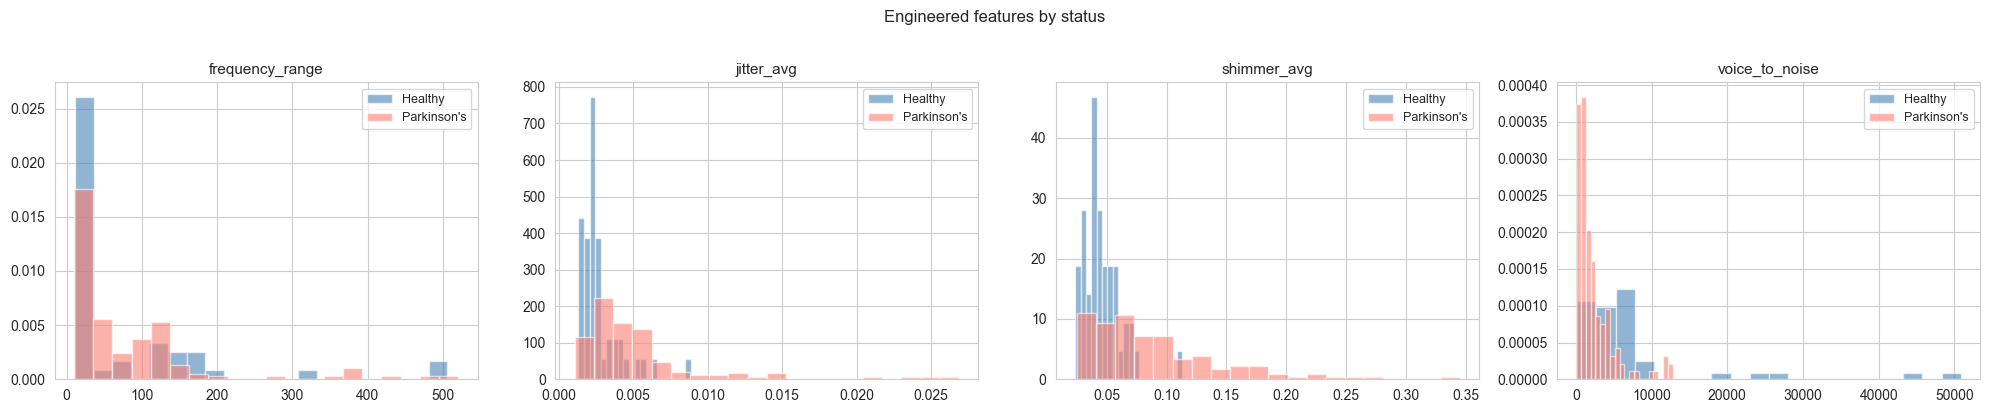

In [7]:
# Visualize new features by status
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(new_cols):
    for s, color, label in [(0, "steelblue", "Healthy"), (1, "salmon", "Parkinson's")]:
        sub = df_feat[df_feat["status"] == s][col]
        axes[i].hist(sub, bins=20, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=11); axes[i].legend(fontsize=9)
plt.suptitle("Engineered features by status", y=1.02)
plt.tight_layout(); plt.show()

## 6. Run the Full Pipeline

In [8]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (195, 27)
Missing values : 0


,Fo_Hz,Fhi_Hz,Flo_Hz,Jitter_pct,Jitter_Abs,RAP,PPQ,Jitter_DDP,Shimmer,Shimmer_dB,...,RPDE,DFA,spread1,spread2,D2,PPE,frequency_range,jitter_avg,shimmer_avg,voice_to_noise
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,82.305,0.005648,0.117662,951.288966
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,34.831,0.007062,0.171578,989.372681
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,19.556,0.008034,0.136636,1577.616381
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,26.505,0.007422,0.145784,1525.794418
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,31.126,0.009648,0.167220,1111.997673


## 7. Sanity Checks & Save

In [9]:
assert df_processed["status"].isin([0, 1]).all()
assert df_processed.isnull().sum().sum() == 0
assert "name" not in df_processed.columns
print("All checks passed.")

All checks passed.


In [10]:
df_processed.to_csv("data/parkinsons_cleaned.csv", index=False)
print(f"Saved data/parkinsons_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/parkinsons_cleaned.csv (195 rows, 27 cols)
